In [ ]:
%%bash
wget -nc -q https://nimbus.niu.edu/courses/EAE483/exam1.csv

# Predicting storm mode using decision trees

In [ ]:
import numpy as np

zid = 1985840

Here is the code that reads in the csv file

In [ ]:
import pandas as pd
np.random.seed(zid)

df = pd.read_csv("exam1.csv")

df['year'] = np.random.randint(1996, 2013, size=len(df))

df

,mean_intensity,intensity_variance,max_intensity,20dbz_area,40dbz_area,50dbz_area,minor_axis_length,major_axis_length,label_name,year
0,29.605934,57.732401,60,94096,13464,1952,419.530526,453.944381,Tropical,2001
1,34.533811,128.394349,60,3904,1620,712,55.788012,131.140329,Unorganized,1997
2,28.455169,67.222373,60,43720,6696,1140,225.857727,348.464842,MCS,2010
3,30.639121,69.126977,65,115252,21320,4532,280.930506,633.947605,MCS,2004
4,29.718766,54.281975,55,123456,18996,1420,429.843309,690.668580,Tropical,1998
...,...,...,...,...,...,...,...,...,...,...
494,36.360410,106.331461,55,5072,2444,868,57.955606,184.277795,Unorganized,2012
495,28.129001,45.379113,50,98728,8904,704,381.684997,418.776487,Tropical,2004
496,33.872195,52.469284,55,40468,11920,1408,188.499491,300.634325,MCS,1999
497,29.026198,112.193729,70,11604,2336,944,133.441552,296.784155,Clutter,2007


# 1. Description

In [ ]:
#descriptive stats
df.describe()

,mean_intensity,intensity_variance,max_intensity,20dbz_area,40dbz_area,50dbz_area,minor_axis_length,major_axis_length,year
count,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000
mean,27.847964,49.260247,50.901804,80572.545090,8137.987976,984.825651,244.292294,504.404697,2004.246493
std,4.382629,34.155056,10.622605,93541.604742,11970.459534,2051.207874,177.416430,390.894230,4.756032
min,20.042433,0.210364,25.000000,2036.000000,0.000000,0.000000,31.567177,67.394953,1996.000000
25%,24.234615,22.182364,45.000000,5314.000000,544.000000,0.000000,81.764385,158.307388,2000.000000
50%,28.275568,44.207924,55.000000,43720.000000,2604.000000,252.000000,193.666770,421.178475,2004.000000
75%,31.225189,73.695541,60.000000,122466.000000,10792.000000,892.000000,386.877972,731.202233,2008.000000
max,37.864026,140.919061,70.000000,443324.000000,71772.000000,20036.000000,840.375537,1939.869146,2012.000000


In [ ]:
#finding if there are any null values in dataset

df.isnull().values.any()

np.False_

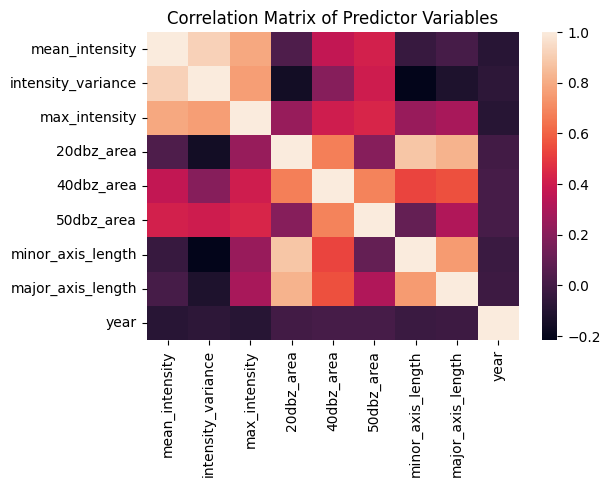

In [ ]:
#correlation
import seaborn as sns
import matplotlib.pyplot as plt
num_cols = df.select_dtypes(include=['int64', 'float64']).columns #selecting numerical columns

plt.figure(figsize=(6, 4))
corr = df[num_cols].corr()

sns.heatmap(corr, annot=False)
plt.title("Correlation Matrix of Predictor Variables")
plt.show()

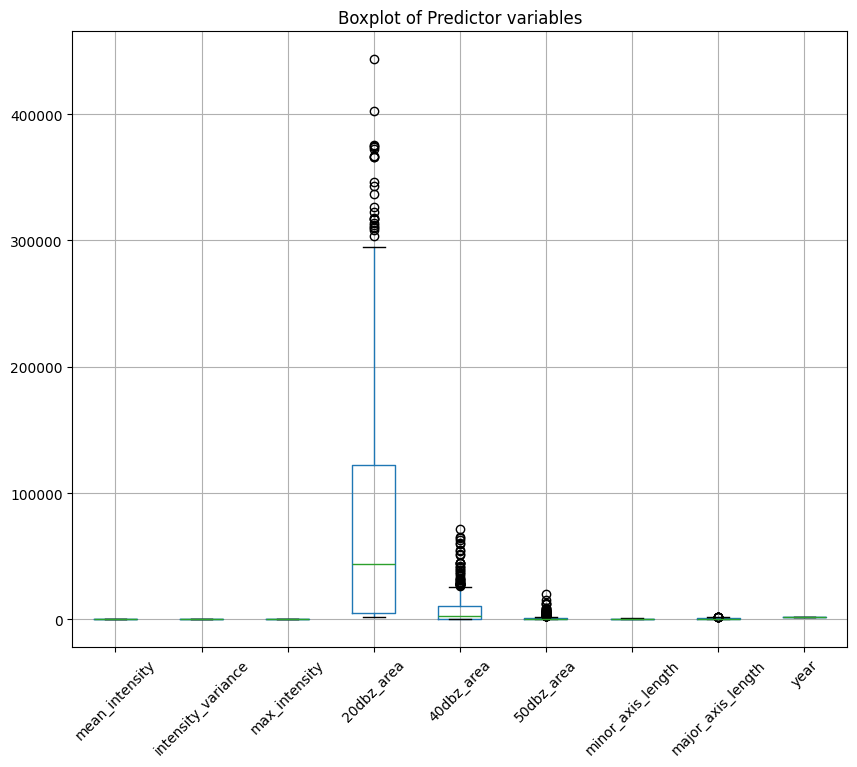

In [ ]:
#box plot

plt.figure(figsize=(10, 8))
df[num_cols].boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot of Predictor variables")
plt.show()

### Noticeable patterns in the dataset:
1. Values of three columns- 20dbz_area, 40dbz_area and 50dbz_area are very high compared to the values of other columns. This may confuse the ML model to put more weightage to high value columns. So, we need to normalize the dataset.
These high value columns also have a high dispersion as shown by the high standard deviation values.
2. There are no null values in dataset.
3. There is a high positive correlation among mean intensity, intensity variance and max intensity variables.
4. There is again a high positive correlation between minor axis length and major axis length variable.

High correlation among the predictor variables may cause the problem of multicolinearity so it's better to either drop correlated variable or perform dimensionality reduction.

5. There are many outliers in 20dbz_area, 40dbz_area and 50dbz_area columns. Since their values are large, the boxplot fails to show the outliers of other columns. So, it's better to first standardize the dataset and then create a boxplot.

# 2. Preprocessing

In [ ]:
#adding another column to the dataframe
df['min_max_ratio'] = df['minor_axis_length'] / df['major_axis_length']
df

,mean_intensity,intensity_variance,max_intensity,20dbz_area,40dbz_area,50dbz_area,minor_axis_length,major_axis_length,label_name,year,min_max_ratio
0,29.605934,57.732401,60,94096,13464,1952,419.530526,453.944381,Tropical,2001,0.924189
1,34.533811,128.394349,60,3904,1620,712,55.788012,131.140329,Unorganized,1997,0.425407
2,28.455169,67.222373,60,43720,6696,1140,225.857727,348.464842,MCS,2010,0.648151
3,30.639121,69.126977,65,115252,21320,4532,280.930506,633.947605,MCS,2004,0.443145
4,29.718766,54.281975,55,123456,18996,1420,429.843309,690.668580,Tropical,1998,0.622358
...,...,...,...,...,...,...,...,...,...,...,...
494,36.360410,106.331461,55,5072,2444,868,57.955606,184.277795,Unorganized,2012,0.314501
495,28.129001,45.379113,50,98728,8904,704,381.684997,418.776487,Tropical,2004,0.911429
496,33.872195,52.469284,55,40468,11920,1408,188.499491,300.634325,MCS,1999,0.627006
497,29.026198,112.193729,70,11604,2336,944,133.441552,296.784155,Clutter,2007,0.449625


### Noticeable patterns in the dataset:
1. Since minor and major axis length variables are correlated, it's better to derive their ratio as another predicting variable.
2. The ratio provides additional information too: values closer to 0 means more circular storms while values closer to 1 indicates enlongated shape of storm system.

# 3. Setting up Machine Learning Subsets

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

df.sort_values(by='year') #checking start and end year

#subsetting training data based on year

df_train = df[df['year'] <= 2008].copy()

#subsetting validation data

df_val = df[(df['year'] > 2008) & (df['year'] <=2010)].copy()

#subsetting testing data

df_test = df[(df['year'] > 2010) & (df['year'] <=2012)].copy()

print("training samples=", len(df_train))
print("validation samples=", len(df_val))
print("testing samples=", len(df_test))


training samples= 378
validation samples= 66
testing samples= 55


Notes:
1. I decided to create subsets based on separate years to minimize data leakage in the model.
2. The validation and test subsets roughly are 10% each of the total data values.


# 4. Training Decision Tree classifier

In [ ]:
#Convert the numerical features to numpy arrays
import numpy as np

numeric_cols = df_train.select_dtypes(include="number").columns.tolist()
x_train = df_train[numeric_cols].to_numpy()
y_train = df_train['label_name'].to_numpy()

x_val = df_val[numeric_cols].to_numpy()
y_val = df_val['label_name'].to_numpy()

x_test = df_test[numeric_cols].to_numpy()
y_test = df_test['label_name'].to_numpy()

#standardize dataset
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)


In [ ]:
#Hyperparameter tuning
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import f1_score, make_scorer, accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier


param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 2, 4, 6, 8, 12],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10]

}

df_params = pd.DataFrame(list(ParameterGrid(param_grid)))

combined_X = np.concatenate([x_train, x_val])
combined_y = np.concatenate([y_train, y_val])

train_idx = [-1.0] * x_train.shape[0]
val_idx = [0.0] * x_val.shape[0]

splits = np.concatenate([train_idx, val_idx])

from sklearn.model_selection import PredefinedSplit

ps = PredefinedSplit(splits)

grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=zid),
    param_grid=param_grid,
    scoring=make_scorer(accuracy_score),
    cv=ps,
    refit=True,
    verbose=1,
    return_train_score=True
)

grid.fit(combined_X, combined_y)

print("Best params:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

Fitting 1 folds for each of 192 candidates, totalling 192 fits
Best params: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV accuracy: 0.9393939393939394


Notes:
1. The predictor variable columns are first converted into numpy arrays which is a requirement for scikitlearn modelling, then these are normalized using standard deviation method.

2. Using GridSearchCV, many combinations of decision tree hyperparameters are tested. Best parameters are chosen based on accuracy score because in this case of multiclass classification- there are F1 or precision or recall for each class so I decided to go for the overall accuracy.



# 5. Assessing the Decision Tree classifier

In [ ]:
best_tree = grid.best_estimator_

y_pred = best_tree.predict(x_test)

sklearn_acc = accuracy_score(y_test, y_pred)
sklearn_cr = classification_report(y_test, y_pred)
sklearn_cm = confusion_matrix(y_test, y_pred)

print("Accuracy score =", sklearn_acc)
print("Classification Report",sklearn_cr)
print("Confusion Matrix =", sklearn_cm)



Accuracy score = 0.8909090909090909
Classification Report               precision    recall  f1-score   support

     Clutter       0.94      0.94      0.94        16
         MCS       1.00      0.78      0.88         9
    Synoptic       0.75      0.90      0.82        10
    Tropical       0.89      0.89      0.89         9
 Unorganized       0.91      0.91      0.91        11

    accuracy                           0.89        55
   macro avg       0.90      0.88      0.89        55
weighted avg       0.90      0.89      0.89        55

Confusion Matrix = [[15  0  1  0  0]
 [ 0  7  1  0  1]
 [ 0  0  9  1  0]
 [ 0  0  1  8  0]
 [ 1  0  0  0 10]]


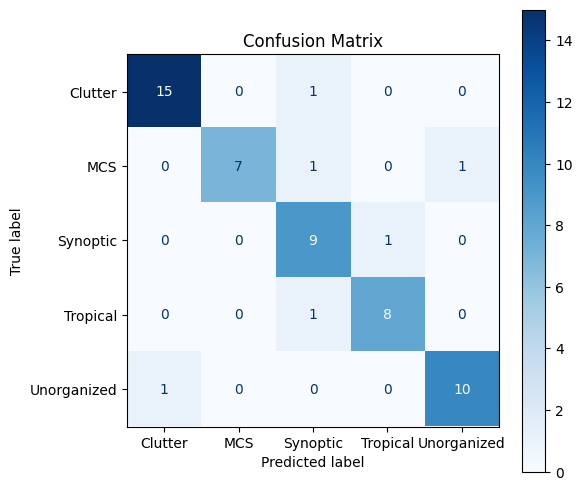

In [ ]:
plt.rcParams['figure.figsize'] = 6, 6

from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_estimator(
        best_tree,
        x_test,
        y_test,
        cmap=plt.cm.Blues,
        normalize=None,
    )
disp.ax_.set_title("Confusion Matrix")

plt.show()

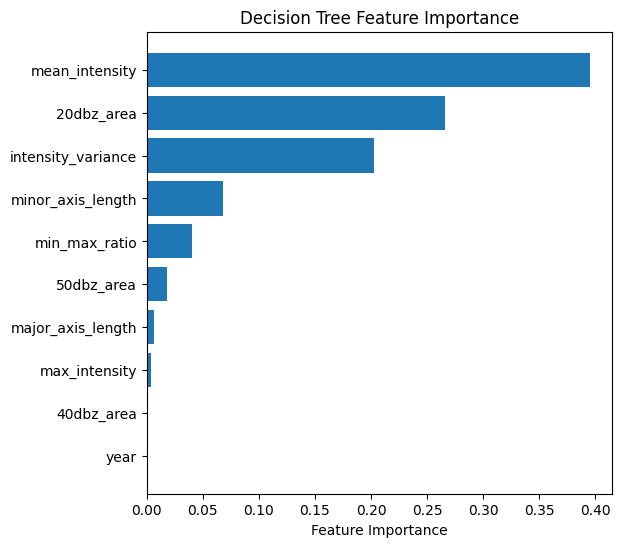

In [ ]:
#Evaluating feature importance

importances = best_tree.feature_importances_

feature_names = df_train.select_dtypes(include="number").columns  # original dataframe before scaling

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

plt.figure()
plt.barh(feat_imp['feature'], feat_imp['importance'])
plt.xlabel("Feature Importance")
plt.title("Decision Tree Feature Importance")
plt.gca().invert_yaxis()
plt.show()

Notes:
1. The overall accuracy on testing dataset is 0.89, which is slightly lower than what the model yielded on validation dataset (0.93)
2. Model generally perfoms well to detect storm modes, except for Synoptic class having the lowest F1 score of 0.82, due to low precision (0.75). Lowest recall (0.78) is for MCS class.
3. Mean intensity, 20 dbz area and intensity variance are top three features whereas year, 40 dbz area, max intensity are bottom three explanatory features.

# 6. Summary

This model follows the basic ML pipeline: starting with data ingestion (storm mode csv), data description (summary statistics, null value detection), data preprocessing (adding another explanatory variable - min max ratio, standardization), data splitting into three sets for training, validation, and testing, training the Decision tree model using various hyperparameters, and lastly, testing the performance of trained model on unseen test set using metrics like overall accuracy, F1 score, precision, and recall. Feature importances are also evaluated at the end.

The model performed slighly worse on the test set than it did on validation set. As discussed in the sections above : Model perfomed well to detect most storm modes. However, for Synoptic class having the lowest F1 score of 0.82, due to low precision (0.75). In simple words, model classifies many storms as Synoptic which in reality are not. Lowest recall (0.78) is for MCS class meaning that model fails to detect many true MCS classes.

Since the model didn't perform as good on test set, it means that the model was overfitted to the training set and could not generalize as well on unseen data. Model performance could be improved by increasing data values in the train, validation and test sets or by using Random Forest classifier, which is an improved version of decision trees.